# Quantum Optics - Homework 4 - Wigner function of a mechanical resonator

## Jan Chelmecki

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

$$
H / \hbar = g_0 (\sigma^+ a + \sigma^- a^{\dag})
$$

Working with this Hamiltonian, we ignore H.O. part, which would induce a rotation (fairly rapid, since $\omega_{phonon} \approx 2\pi \cdot 6 GHz$) of the oscillator's Wigner function, which is also why we also ignore the phase of the coherent state. I choose the amplitude to be a negative number to roughly match the graphs.

In [153]:
alpha = -1.75
N = 15
g0 = 2*np.pi*0.258 # 2\pi * 258 kHz  ~ 1.6 Ghz -----> It is numerically OK to use dimensionfull values, provided that we measure time in microseconds
om_qubit = 2*np.pi*5.9456 #GHz
om_phonon = 2*np.pi*5.9614 #GHz

t_R =  2*np.pi*abs(alpha)/g0
T = 10
dt = 0.01; N_Steps = int(T/dt)
times = np.linspace(0,T,N_Steps+1)
print("t_R = ", t_R)

xmax = 4
xvec = np.linspace(-xmax,xmax,201)
yvec = np.linspace(-xmax,xmax,201)

g = basis(2,0)
e = basis(2,1)

H = g0* ( tensor(destroy(2).dag(), destroy(N)) + tensor(destroy(2), destroy(N).dag()) )
#+ om_qubit/2 * tensor(sigmaz(), qeye(N))

t_R =  6.782945736434109


In [154]:
psi0 = tensor(g, coherent(N,alpha))
rho0 = psi0*psi0.dag()
result = mesolve(H, rho0, times)

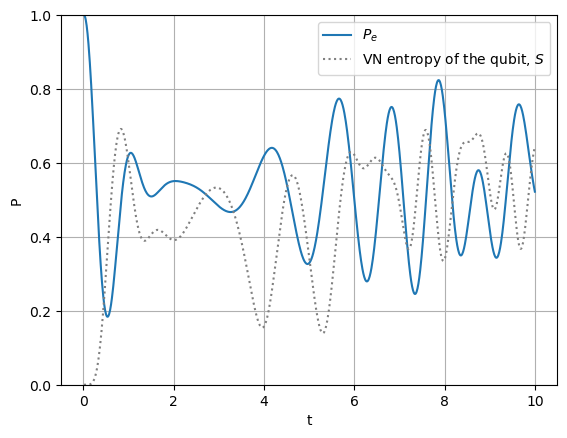

In [155]:
rho_qubit = [result.states[i].ptrace(0) for i in range(N_Steps)]
Prob_e = np.real(np.array ([ rho_qubit[i][0,0] for i in range(N_Steps) ]))
S = [entropy_vn(rho_q) for rho_q in rho_qubit]
plt.plot(times[1::], Prob_e, label="$P_e$")
plt.plot(times[1::], S, label = "VN entropy of the qubit, $S$", linestyle=":", color="gray")
plt.xlabel("t"); plt.ylabel("P")
plt.ylim(0,1)
plt.grid()
plt.legend()

3.3914728682170545


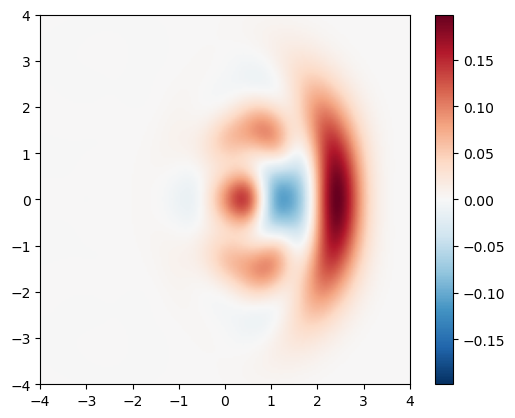

In [158]:
t = t_R/2
print(t)
rho = result.states[int(N_Steps*t_R/T)].ptrace(1)
W = wigner(rho, xvec, yvec)
W_max = np.max(abs(W))
plt.imshow(W,cmap="RdBu_r",vmin=-W_max,vmax=W_max, extent=[-xmax,xmax,-xmax,xmax], aspect=1)
plt.colorbar()

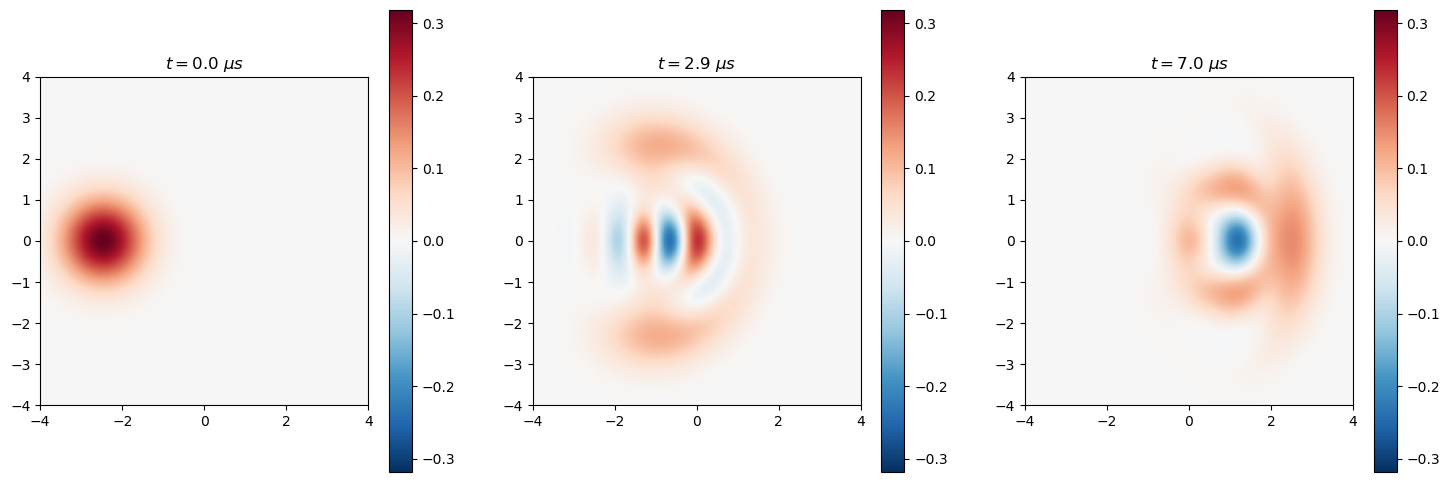

In [159]:
time_obs = [0.0, 2.9, 7.0]
rho = [result.states[int(N_Steps/T*time_obs[i])].ptrace(1) for i in range(3)]
W = [wigner(rho[i], xvec, yvec) for i in range(3)]
W_max = np.max([np.max(W[i]) for i in range(3)])

f, ax = plt.subplots(1, 3, figsize=[18,6])
for i in range(3):
    im = ax[i].imshow(W[i],cmap="RdBu_r",vmin=-W_max,vmax=W_max, extent=[-xmax,xmax,-xmax,xmax], aspect=1)
    ax[i].set_title("$t = "+str(time_obs[i])+" \; \mu s$")
    f.colorbar(im)

# Different amplitudes

The amplitude $|\beta|$ of the prepared coherent state depends on the microwave drive amplitude $A$, the latter being referenced as true the control parameter. However, for numerical simulations, it's really $\beta$ that we need. To measure it for a given $A$, the authors extract the Fock state populations from the time variation of the qubit populations and fit a Poisson distribution to get $|\beta|$. For three different types of pulses, the experimental $\beta(A)$ dependence matches the phenomenological fit $\beta = C (\exp(A/B) -1)$ (cf. figure S3 C in the Supplementary Material). 

Sadly, I cannot find $B$ and $C$ or a mention which type of signal was used to produce the measurement presented in the main text, which means I cannot get the same value of $\beta$ that the researchers used. 

A way out is to consider the function $\beta(A)$ to be linear in the 0-0.35 range (this seems reasonable when compared with figure S3).

2.9069767441860472


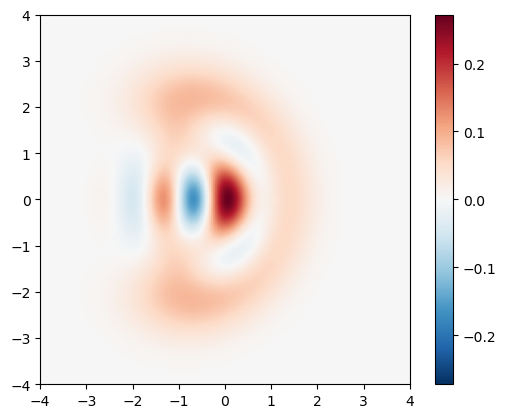

In [181]:
alpha = -1.75 * 0.30/0.35
t_R =  2*np.pi*abs(alpha)/g0
psi0 = tensor(g, coherent(N,alpha))
rho0 = psi0*psi0.dag()
result = mesolve(H, rho0, times)

t = t_R/2
print(t)
rho = result.states[int(N_Steps*t/T)].ptrace(1)
W = wigner(rho, xvec, yvec)
W_max = np.max(abs(W))
plt.imshow(W,cmap="RdBu_r",vmin=-W_max,vmax=W_max, extent=[-xmax,xmax,-xmax,xmax], aspect=1)
plt.colorbar()

2.4224806201550386
2.9069767441860472
3.3914728682170545


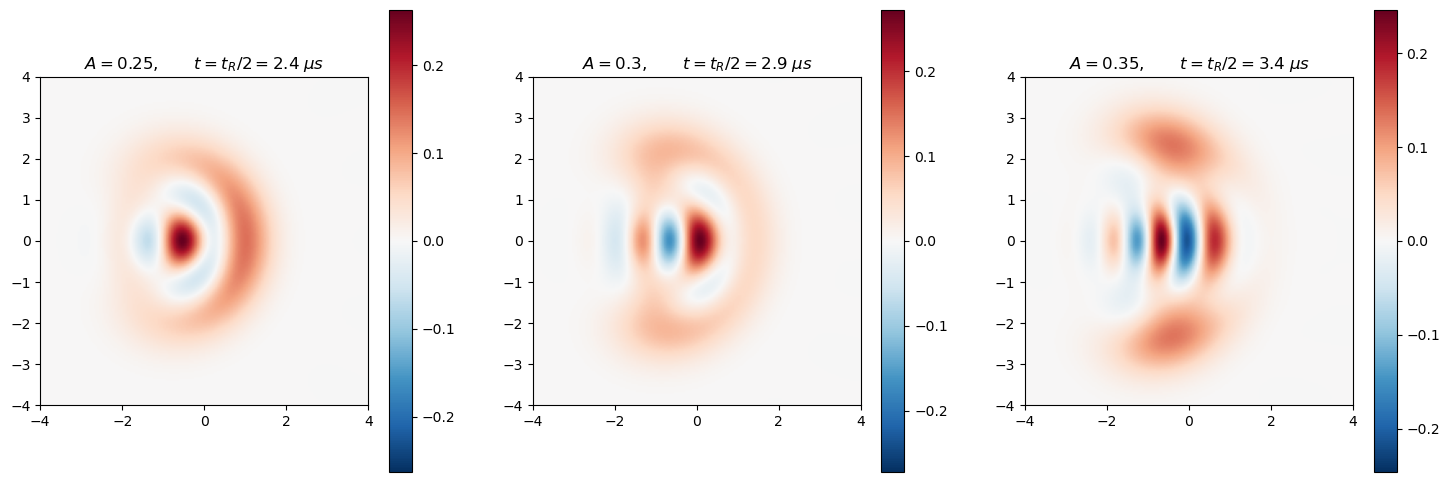

In [188]:
A = [0.25, 0.30, 0.35]
f, ax = plt.subplots(1, 3, figsize=[18,6])
for i in range(3):
    alpha = -1.75 * A[i]/0.35
    t_R =  2*np.pi*abs(alpha)/g0
    psi0 = tensor(g, coherent(N,alpha))
    rho0 = psi0*psi0.dag()
    result = mesolve(H, rho0, times)

    t = t_R/2
    print(t)
    rho = result.states[int(N_Steps*t/T)].ptrace(1)
    W = wigner(rho, xvec, yvec)
    W_max = np.max(abs(W))
    im = ax[i].imshow(W,cmap="RdBu_r",vmin=-W_max,vmax=W_max, extent=[-xmax,xmax,-xmax,xmax], aspect=1)
    ax[i].set_title("$A = "+str(A[i])+", \qquad t = t_R/2 = "+str(round(t,1))+"\; \mu s $")
    f.colorbar(im)

2.9


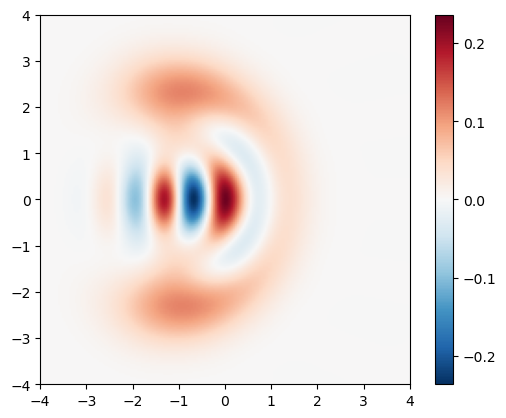

In [190]:
t = 2.9
print(t)
rho = result.states[int(N_Steps*t/T)].ptrace(1)
W = wigner(rho, xvec, yvec)
W_max = np.max(abs(W))
plt.imshow(W,cmap="RdBu_r",vmin=-W_max,vmax=W_max, extent=[-xmax,xmax,-xmax,xmax], aspect=1)
plt.colorbar()